<a href="https://colab.research.google.com/github/Thujaina/ECG-classification---AlexNet/blob/main/categorical_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from keras.models import Model
from keras.layers import Input
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

In [5]:
train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


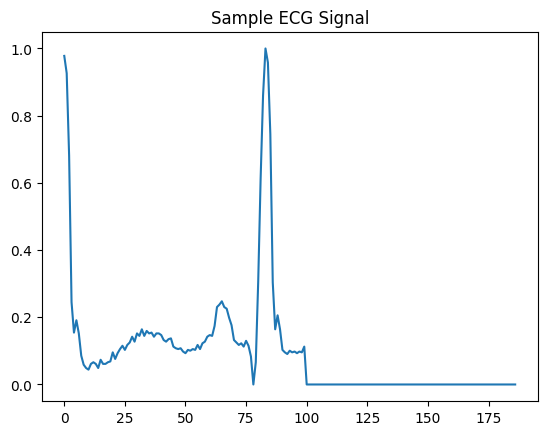

In [6]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

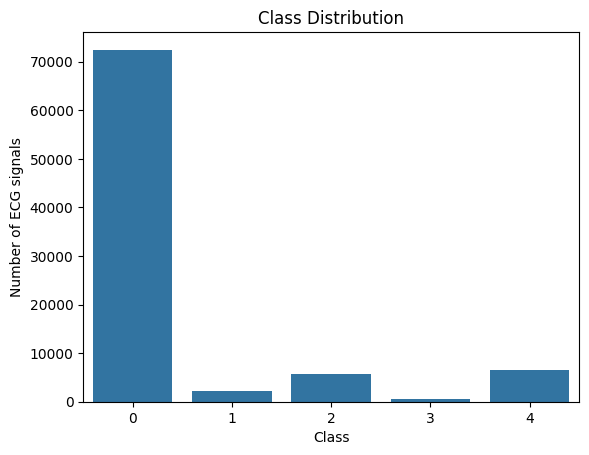

In [7]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [8]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [9]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [10]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [11]:
print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [12]:
X_res = X_res[:120000]
y_res = y_res[:120000]

In [13]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [15]:
X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [16]:
def alexnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(384, kernel_size=3, activation='relu', padding='same')(x)
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)

    x = MaxPooling1D(pool_size=3, strides=2)(x)

    x = Flatten()(x)

    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [17]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr = to_categorical(y_res[train_idx], 5)
    y_va = to_categorical(y_res[val_idx], 5)

    model = alexnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=128,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)
print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 309s 484ms/step - accuracy: 0.8673 - loss: 0.3723
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 306s 489ms/step - accuracy: 0.9538 - loss: 0.1372
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 300s 480ms/step - accuracy: 0.9683 - loss: 0.0967
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 477ms/step - accuracy: 0.9751 - loss: 0.0751
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 477ms/step - accuracy: 0.9790 - loss: 0.0642
Fold 1 Accuracy: 0.9733

Fold 2
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 482ms/step - accuracy: 0.8501 - loss: 0.4100
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 328s 492ms/step - accuracy: 0.9473 - loss: 0.1560
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 307s 492ms/step - accuracy: 0.9651 - loss: 0.1050
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 308s 494ms/step - accuracy: 0.9741 - loss: 0.0789
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 488ms/step - accuracy: 0.9789 - loss: 0.0669
Fold 2 Accuracy: 0.9790

Fold 3
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━

In [18]:
model = alexnet_ecg()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 397s 524ms/step - accuracy: 0.8809 - loss: 0.3332 - val_accuracy: 0.9442 - val_loss: 0.1638
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 439s 520ms/step - accuracy: 0.9569 - loss: 0.1284 - val_accuracy: 0.9685 - val_loss: 0.0897
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 441s 519ms/step - accuracy: 0.9704 - loss: 0.0895 - val_accuracy: 0.9701 - val_loss: 0.0909
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 387s 515ms/step - accuracy: 0.9775 - loss: 0.0705 - val_accuracy: 0.9785 - val_loss: 0.0669
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 385s 513ms/step - accuracy: 0.9816 - loss: 0.0585 - val_accuracy: 0.9820 - val_loss: 0.0556
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 392s 523ms/step - accuracy: 0.9833 - loss: 0.0531 - val_accuracy: 0.9846 - val_loss: 0.0505
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 439s 519ms/step - accuracy: 0.9861 - loss: 0.0438 - val_accuracy: 0.9877 - val_loss: 0.0408
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 433s 508ms/step - accuracy: 0.9873 -

In [19]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step
Validation MCC: 0.9759542649639117


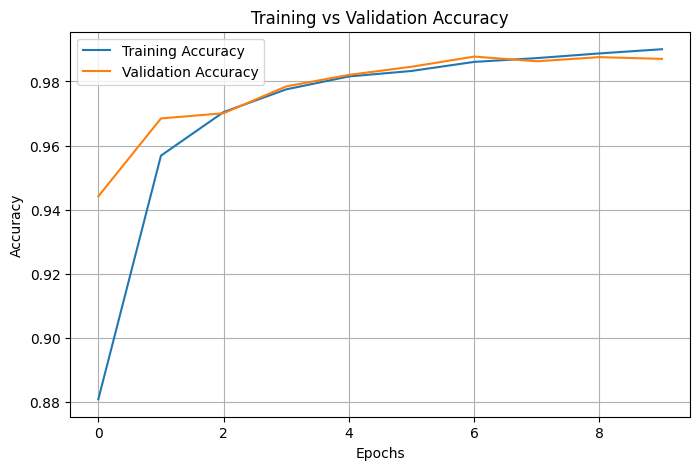

Final Training Accuracy: 0.9901
Final Validation Accuracy: 0.9870


In [21]:
# Cell 24: Accuracy Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

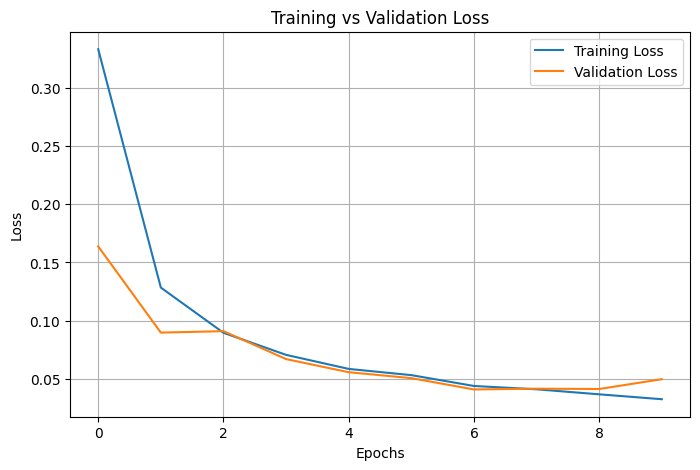

Final Training Loss: 0.0324
Final Validation Loss: 0.0496


In [22]:
# Cell 25: Loss Graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.1003
Test Accuracy: 0.9783


In [24]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.68      0.88      0.77       556
         2.0       0.97      0.94      0.96      1448
         3.0       0.85      0.69      0.76       162
         4.0       1.00      0.98      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.90      0.89     21892
weighted avg       0.98      0.98      0.98     21892



In [27]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
num_classes = cm.shape[0]

# Lists
precision = []
recall = []
f1 = []
specificity = []
support = []

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    prec = TP / (TP + FP) if (TP + FP) != 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) != 0 else 0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0
    f1_score = (2 * prec * rec) / (prec + rec) if (prec + rec) != 0 else 0

    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)
    specificity.append(spec)
    support.append(np.sum(cm[i, :]))

# Convert to numpy
precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)
specificity = np.array(specificity)
support = np.array(support)

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)

# Macro Average
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_spec = np.mean(specificity)

# Weighted Average
weights = support / np.sum(support)

weighted_precision = np.sum(precision * weights)
weighted_recall = np.sum(recall * weights)
weighted_f1 = np.sum(f1 * weights)
weighted_spec = np.sum(specificity * weights)

# Create DataFrame
report_df = pd.DataFrame({
    "precision": precision,
    "recall": recall,
    "f1-score": f1,
    "specificity": specificity,
    "support": support
})

report_df.index = [f"Class {i}" for i in range(num_classes)]

# Add summary rows
summary_df = pd.DataFrame({
    "precision": [accuracy, macro_precision, weighted_precision],
    "recall":    [accuracy, macro_recall, weighted_recall],
    "f1-score":  [accuracy, macro_f1, weighted_f1],
    "specificity": [np.nan, macro_spec, weighted_spec],
    "support":   [np.sum(support), np.sum(support), np.sum(support)]
}, index=["accuracy", "macro avg", "weighted avg"])

# Combine
final_df = pd.concat([report_df, summary_df])

# Print
print(final_df.round(3))

685/685 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step
              precision  recall  f1-score  specificity  support
Class 0           0.990   0.987     0.988        0.951    18118
Class 1           0.680   0.883     0.768        0.989      556
Class 2           0.972   0.940     0.956        0.998     1448
Class 3           0.855   0.691     0.765        0.999      162
Class 4           0.998   0.978     0.988        1.000     1608
accuracy          0.978   0.978     0.978          NaN    21892
macro avg         0.899   0.896     0.893        0.987    21892
weighted avg      0.980   0.978     0.979        0.959    21892


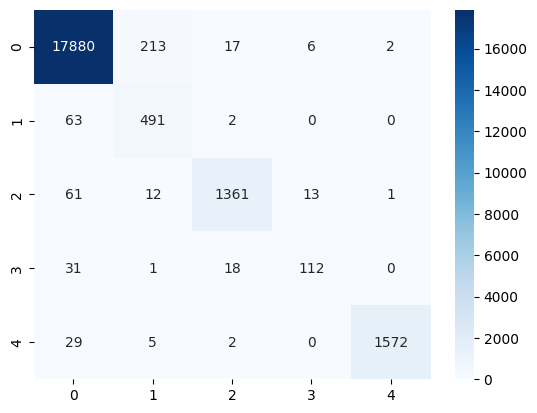

In [28]:
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()